# 09 — Size Sweep: How Small Can a Student Go?

You have already seen that knowledge distillation can transfer a teacher's factual
recall into a student model. But distillation always involves a choice: *how large
should the student be?* A bigger student has more **model capacity** — more room to
store knowledge — but also costs more to run at inference time. A smaller student is
cheaper, but may not have enough capacity to hold the facts at all.

This notebook answers that question empirically. We train **three student sizes** —
tiny, mid, and full — all distilled from the same teacher checkpoint, all with the
same random seed, the same alpha, and the same temperature. The only variable that
changes is how many parameters each student has.

> **Model capacity** is the amount of information a neural network can store in its
> weights. It is primarily determined by the total number of **parameters** —
> the individual learnable numbers (weights and biases) spread across all layers.
> A model with more parameters can represent more complex functions and memorise
> more facts, but it costs more memory and compute.

## What you will see

- **Tiny student (~0.10M parameters):** cloze accuracy ≈ **10.0%** — barely above
  random guessing. At this size the student simply does not have enough capacity to
  hold the facts, even with a good distillation signal.
- **Mid student (~0.30M parameters):** cloze accuracy ≈ **17.5%** — a modest
  improvement, but still far from usable. More capacity helps, but the capability
  cliff has not yet been crossed.
- **Full student (~0.79M parameters):** cloze accuracy ≈ **95.0%** — near-perfect
  recall. Above a threshold capacity, the student can learn every fact reliably.

This steep jump — from 17.5% to 95% over a 2.6× increase in parameters — is called
a **capability cliff**: a non-linear threshold below which a model cannot reliably
perform a task, and above which it can. Capability cliffs are common in language
models; they explain why shrinking a model too aggressively can destroy a capability
entirely rather than degrade it gracefully.

## Why more steps (600)?

Earlier distillation notebooks used fewer training steps. Here we use `STEPS = 600`
because smaller models learn more slowly: they have fewer parameters to accumulate
gradient signal, so they need more iterations to converge. Using the same step count
across all sizes ensures the comparison is fair — each model gets the same total
training budget — and 600 steps is enough for the full student to reach near-perfect
recall.

## What to watch

The plot saved to `assets/09_size_sweep.png` shows cloze accuracy (y-axis) versus
parameter count in millions (x-axis) for the three students. The near-flat region
at the left (tiny → mid) and the steep rise to the right (mid → full) visually
illustrate the capability cliff. The assert at the end of the notebook checks the
weakest possible claim — that the largest student recalls at least as well as the
smallest — which would fail only if something had gone wrong in training.

In [1]:
import os, sys
while not os.path.exists("requirements.txt"):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():
        break
    os.chdir(parent)
if os.getcwd() not in sys.path:           # so `import model`/`facts` work as a script
    sys.path.insert(0, os.getcwd())

import json
import torch
import matplotlib.pyplot as plt
from model import GPT, GPTConfig, make_student, make_tiny_student
from distill import train_distill
from facts import build_factset, render_training_corpus, encode, evaluate_cloze

device = (torch.device("cuda") if torch.cuda.is_available()
          else torch.device("mps") if torch.backends.mps.is_available()
          else torch.device("cpu"))

def update_metrics(key, value, path="assets/distill_metrics.json"):
    os.makedirs("assets", exist_ok=True)
    m = json.load(open(path)) if os.path.exists(path) else {}
    m[key] = value
    json.dump(m, open(path, "w"), indent=2)
    return m

In [2]:
ckpt = torch.load("checkpoints/teacher_injected.pt", weights_only=True)
stoi, itos = ckpt["stoi"], ckpt["itos"]
vocab_size = len(stoi)
teacher = GPT(GPTConfig(**ckpt["config"])).to(device)
teacher.load_state_dict(ckpt["model_state"])
teacher.eval()
facts = build_factset()

block_size = 256
corpus = render_training_corpus(facts, repeats=40)
data = torch.tensor(encode(corpus, stoi), dtype=torch.long)

def get_batch(batch_size=32):
    ix = torch.randint(len(data) - block_size - 1, (batch_size,))
    x = torch.stack([data[i:i + block_size] for i in ix])
    y = torch.stack([data[i + 1:i + 1 + block_size] for i in ix])
    return x.to(device), y.to(device)

best_alpha = json.load(open("assets/distill_metrics.json")).get("best_alpha", 0.5)

## Distill each size

We define three student configurations:

| Name | Layers | Heads | Embedding dim | Approx. params |
|------|--------|-------|---------------|----------------|
| `tiny` | (small, see `make_tiny_student`) | — | — | ~0.10M |
| `mid` | 3 | 4 (2 KV) | 96 | ~0.30M |
| `student` | (default, see `make_student`) | — | — | ~0.79M |

**Why a fresh, identically-seeded student for each size?**

Each size starts from `torch.manual_seed(0)` before its weights are initialised.
This is a *controlled comparison*: by fixing the random seed we ensure that any
difference in cloze accuracy is caused by the model's capacity, not by a lucky or
unlucky random initialisation. If we used different seeds, we could not tell whether
a small model failed because it was too small, or simply because it happened to start
from a bad initial state.

All three runs share the same `best_alpha` (loaded from the distillation metrics
saved by notebook 07) and `temperature=1.0`. The teacher checkpoint, training
corpus, and batch sampler are also identical across runs. The only difference is
the `GPTConfig` passed to `GPT(cfg)`.

After training each student, `evaluate_cloze` runs the held-out probe (the same
probe from notebook 01) and records the accuracy. `num_params()` returns the exact
parameter count, which we store alongside the name and accuracy in `sweep`.

In [3]:
mid = GPTConfig(vocab_size=vocab_size, block_size=block_size,
                n_layer=3, n_head=4, n_kv_head=2, n_embd=96, dropout=0.1)
configs = [("tiny", make_tiny_student(vocab_size, block_size)),
           ("mid", mid),
           ("student", make_student(vocab_size, block_size))]

STEPS = 600
sweep = []
for name, cfg in configs:
    torch.manual_seed(0)
    student = GPT(cfg).to(device)
    train_distill(student, teacher, get_batch, steps=STEPS, lr=3e-4, device=device,
                  alpha=best_alpha, temperature=1.0)
    c = evaluate_cloze(student, stoi, itos, facts, device)
    p = student.num_params()
    sweep.append((name, p, c))
    print(f"{name:8s} | {p/1e6:.2f}M params | cloze {c:.1%}")

tiny     | 0.10M params | cloze 10.0%


mid      | 0.30M params | cloze 17.5%


student  | 0.79M params | cloze 95.0%


## Plot cloze vs size

The plot below maps each student onto a 2D space: x = parameter count (in millions),
y = cloze accuracy. Three annotated points appear — one per size — connected by a
line to make the trend readable.

### What the curve reveals

- The **tiny → mid** segment is nearly flat. Both models recall facts poorly, despite
  mid having three times as many parameters. This plateau signals that neither model
  has crossed the capacity threshold needed for reliable fact storage.
- The **mid → full** segment is a sharp vertical jump to ~95%. This is the capability
  cliff: a relatively modest increase in parameters produces an enormous gain in
  factual recall. Below the cliff, more parameters barely help. Above it, the task is
  essentially solved.

### The assert

```python
assert sweep[-1][2] >= sweep[0][2]
```

`sweep[-1]` is the full student (largest), `sweep[0]` is the tiny student (smallest).
This checks the directional claim: the largest model must not be *worse* than the
smallest. It is a weak but meaningful sanity check — it would fail if, for example,
training diverged for the full student, or if the configs were listed in the wrong
order. It does not assert the magnitude of the gap, only its sign.

The metrics are written to `assets/distill_metrics.json` under the key `size_sweep`
so that the capstone notebook (10) can read the full sweep table without re-running
training.

Saved assets/09_size_sweep.png
Continue to 10_capstone.


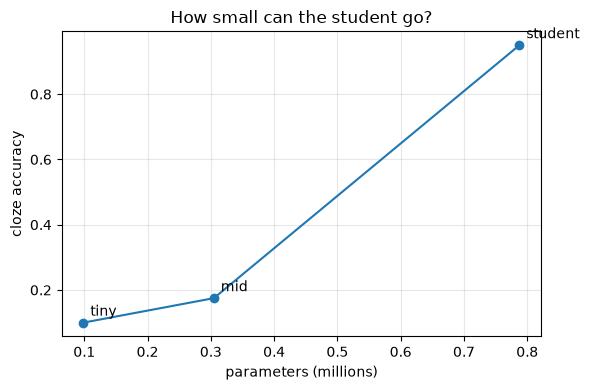

In [4]:
ps = [p for _, p, _ in sweep]
cs = [c for _, _, c in sweep]
plt.figure(figsize=(6, 4))
plt.plot([p / 1e6 for p in ps], cs, "o-")
for name, p, c in sweep:
    plt.annotate(name, (p / 1e6, c), textcoords="offset points", xytext=(5, 5))
plt.xlabel("parameters (millions)")
plt.ylabel("cloze accuracy")
plt.title("How small can the student go?")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("assets/09_size_sweep.png", dpi=120)
print("Saved assets/09_size_sweep.png")

assert sweep[-1][2] >= sweep[0][2], "the largest student should recall at least as well as the smallest"
update_metrics("size_sweep", [[p, c] for _, p, c in sweep])
print("Continue to 10_capstone.")